# Test en Machine Learning
## Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [500]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [501]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Etape 3 : Afficher un échontillon du dataframe

In [502]:
df.head(10)

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.000000,1.000000,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.000000,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.000000,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.000000,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.000000,1.000000,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
5,32.954775,43.962633,0.000000,0.352356,4.0,3.295478,Plastique,Usine_B,Déchet plastique collecté à l'Usine B. Poids 3...
6,187.760007,400.170299,0.000000,0.012702,8.0,5.632800,Verre,Collecte_Citoyenne,Déchets en verre identifiés lors d'une collect...
7,132.167170,252.346840,0.000000,0.011275,9.0,3.965015,Verre,Collecte_Citoyenne,Déchets en verre identifiés via la collecte ci...
8,16.712285,71.655161,0.000000,1.000000,1.0,0.835614,Papier,Usine_A,Feuilles et cartons collectés provenant de l'U...
9,60.078655,121.096923,0.953797,1.000000,7.0,18.023597,Métal,Centre_Tri,Métal de récupération au centre de tri municip...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [503]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### Etape 5 : Afficher la description du dataset

In [504]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [506]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [507]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [508]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [509]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [510]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [511]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [512]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [513]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [514]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [515]:
df.shape

(9724, 9)

In [516]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


- Afficher le nombre de colonne 

In [517]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [518]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie           511
Source              535
Rapport_Collecte      0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [519]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [520]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


- Utilisation de la méthode MAR pour voir le pourcentage de Poids manquant par catégorie

In [521]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

print("Pourcentage de Poids manquant par catégorie :")
display(df.groupby("Categorie")["Poids_missing"].mean() * 100)

print("Pourcentage de Poids manquant par source :")
display(df.groupby("Source")["Poids_missing"].mean() * 100)

Pourcentage de Poids manquant par catégorie :


Categorie
Métal        11.095700
Papier        9.268061
Plastique    10.733802
Verre         8.892617
Name: Poids_missing, dtype: float64

Pourcentage de Poids manquant par source :


Source
Centre_Tri             9.377818
Collecte_Citoyenne    10.419210
Usine_A               10.185968
Usine_B               10.381750
Name: Poids_missing, dtype: float64

- utilisation de la méthode MCAR pour détecter si les NaN sont indépendants

In [522]:
df["Poids_missing"] = df["Poids"].isna().astype(int)

df.groupby("Categorie")["Poids_missing"].mean()

Categorie
Métal        0.110957
Papier       0.092681
Plastique    0.107338
Verre        0.088926
Name: Poids_missing, dtype: float64

=>L’analyse des valeurs manquantes de la variable Poids a été réalisée en étudiant leur distribution selon la catégorie et la source. 
Les résultats montrent que le pourcentage de valeurs manquantes reste relativement stable entre les différentes catégories (entre 8.89% et 11.09%) et les différentes sources (entre 9.37% et 10.41%). 
Cela indique que les valeurs manquantes ne dépendent pas des variables observées. 
Par conséquent, ces données peuvent être considérées comme MCAR (Missing Completely At Random). 
Dans ce cas, une imputation simple comme la médiane est appropriée, tout en comparant avec des méthodes plus avancées comme KNNImputer.

=> Les valeurs manquantes de la variable Poids ne semblent pas totalement aléatoires.
Elles varient selon la catégorie ou la source, donc elles peuvent être considérées comme MAR.
Pour cette raison, plusieurs stratégies d’imputation sont comparées : médiane, KNNImputer et IterativeImputer.

-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [523]:
df["Categorie"] = df["Categorie"].fillna(df["Categorie"].mode()[0])
print(df["Categorie"])
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])

0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object
0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9724, dtype: object


=> Les valeurs manquantes de la variable cible Categorie ont été supprimées afin d’éviter d’introduire un biais dans le modèle.
Pour la variable catégorielle Source, les valeurs manquantes ont été remplacées par la modalité la plus fréquente (ou par une catégorie "Inconnu").

- Vérifier que les Nan pour les variables catégorique sont traités

In [524]:
print(df.isna().sum())

Poids               974
Volume              537
Conductivite        972
Opacite             989
Rigidite            554
Prix_Revente        533
Categorie             0
Source                0
Rapport_Collecte      0
Poids_missing         0
dtype: int64


- Traiter les Nan des variables numérique

In [525]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [526]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus 

In [527]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
Poids_missing       0
dtype: int64


- Voir un échantillon du dataset aprés le traitement des Nan

In [528]:
df.shape

(9724, 10)

### Etape 11 :  La dataset est Equilibre ou Non

In [529]:
df["Categorie"].value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [530]:
#Le dataset présente un léger déséquilibre entre les classes. 
#La classe "Plastique" est dominante par rapport aux autres classes. 
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

- Equilibrer la dataset avec class_weight

In [531]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced")

### Etape 12 : La corrélation entre les variables

<Axes: >

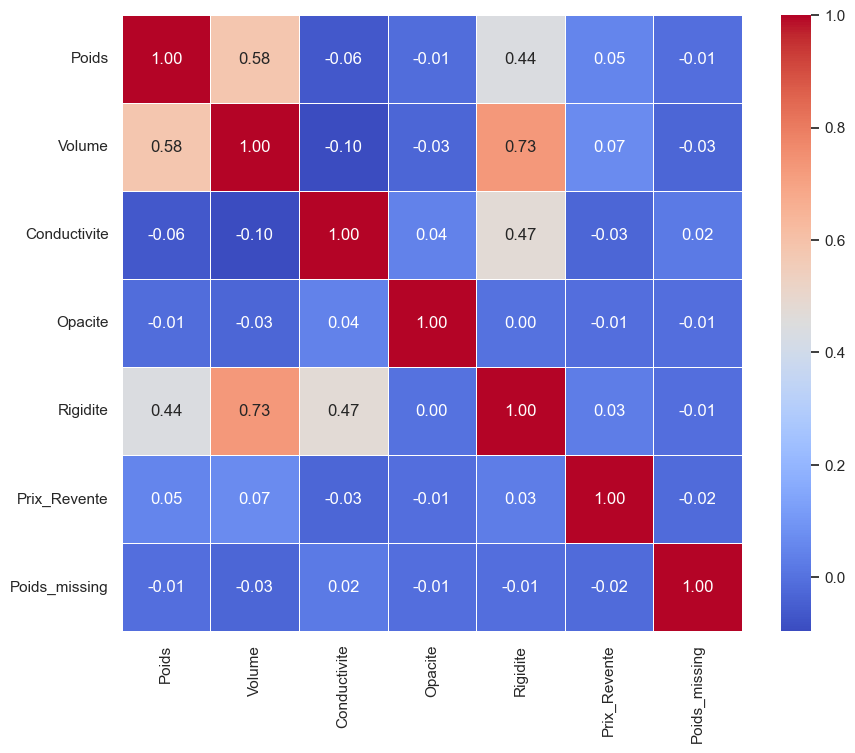

In [532]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

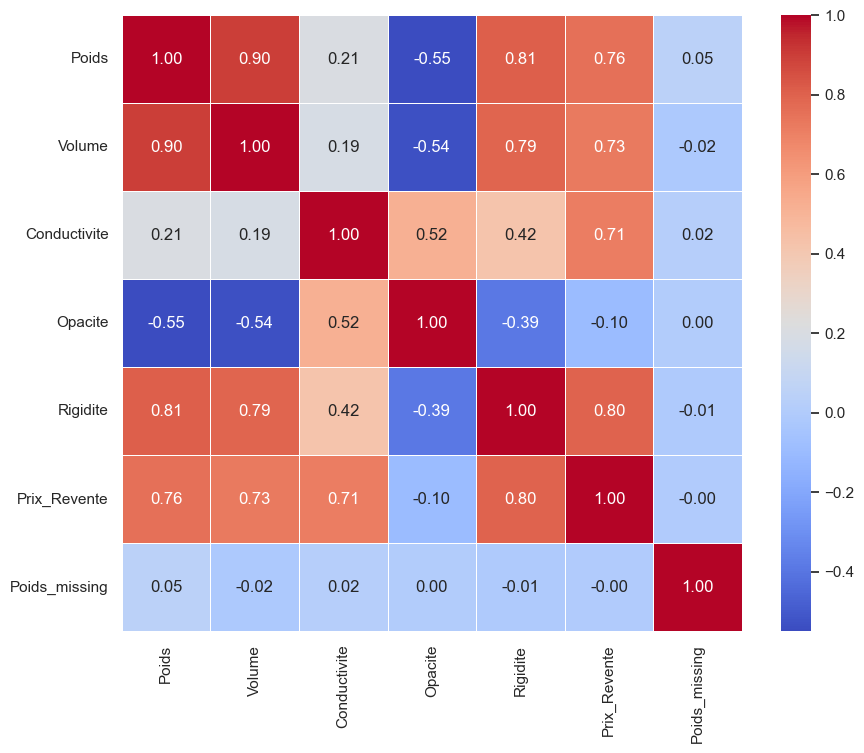

In [533]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

<Axes: >

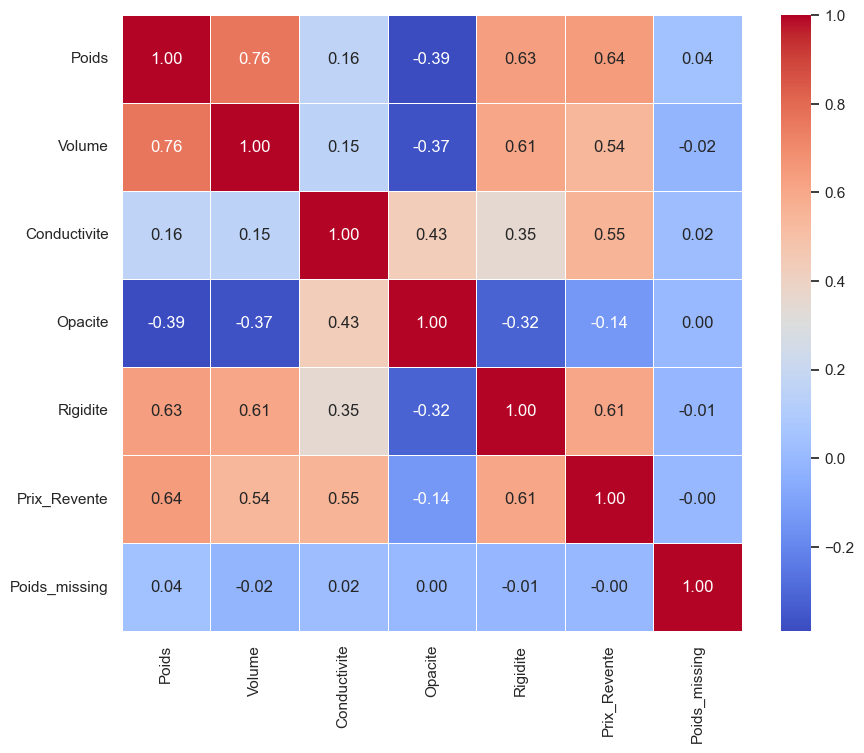

In [534]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

=> Dans ce travail, nous avons utilisé plusieurs méthodes de corrélation pour analyser les relations entre les variables. 
La corrélation de Pearson permet de mesurer les relations linéaires entre les variables numériques. 
La corrélation de Spearman est utilisée pour détecter des relations même non linéaires et elle est plus robuste face aux valeurs aberrantes. 
Enfin, la corrélation de Kendall, plus précise mais plus lente, peut être utilisée pour confirmer les résultats. 
Ces méthodes permettent de mieux comprendre les liens entre les variables.

### Etape 13 : Traiter les outliers

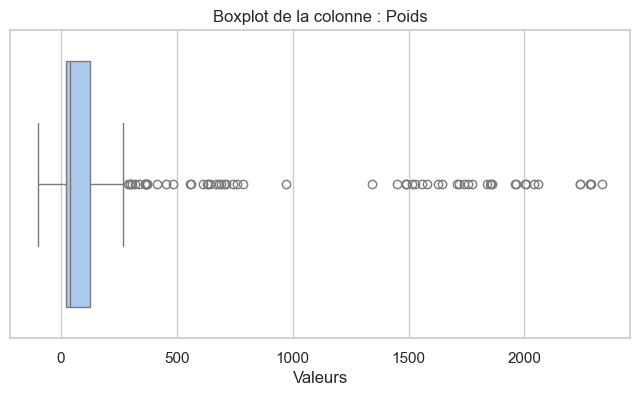

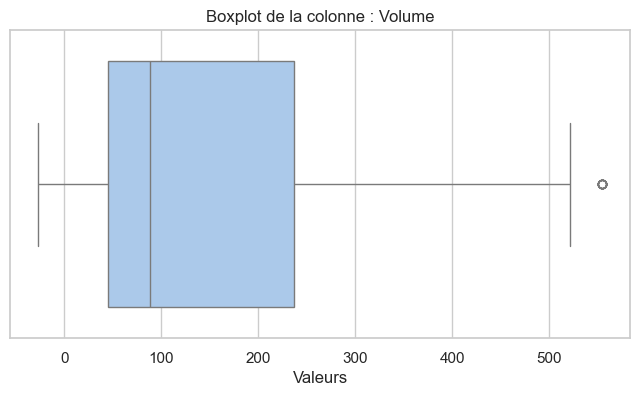

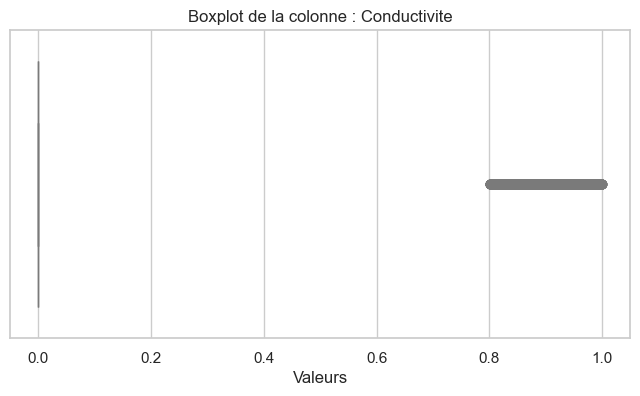

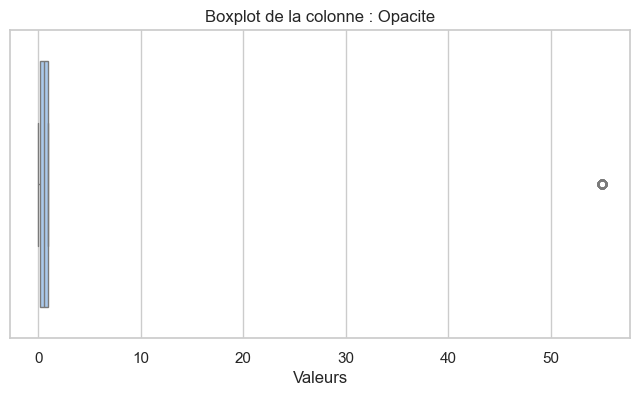

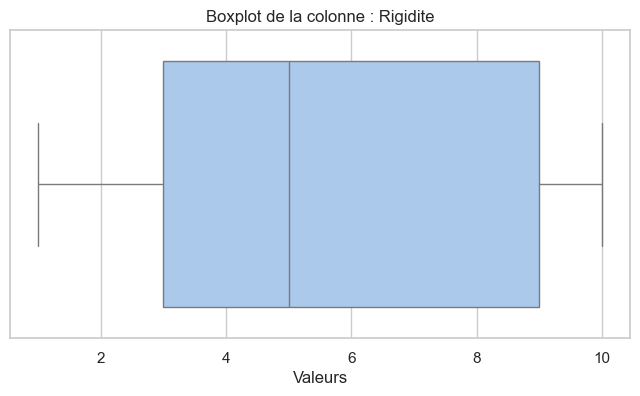

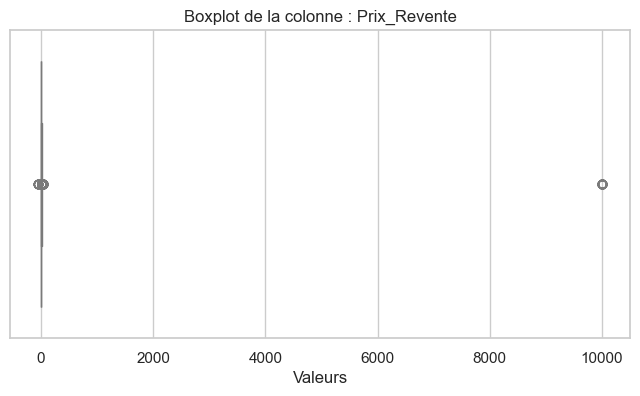

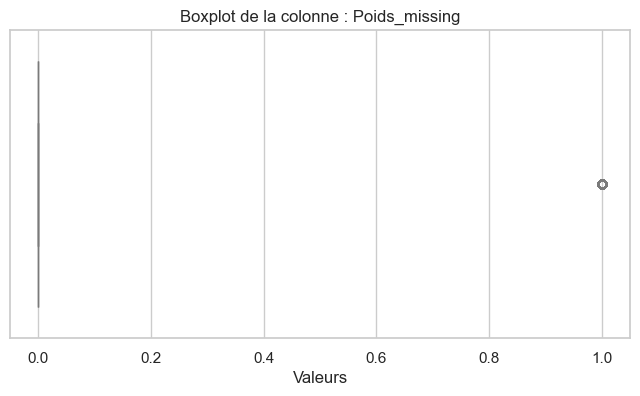

In [535]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

- Traiter les valeurs outilers par la méthode de Quartile

In [536]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


In [537]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR

df = df[(df['Poids'] >= inf) & (df['Poids'] <= sup)]


In [538]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


In [539]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


In [540]:
Q1 = df['Opacite'].quantile(0.25)
Q3 = df['Opacite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Opacite'] >= inf) & (df['Opacite'] <= sup)]


- vérifier la modification des VA

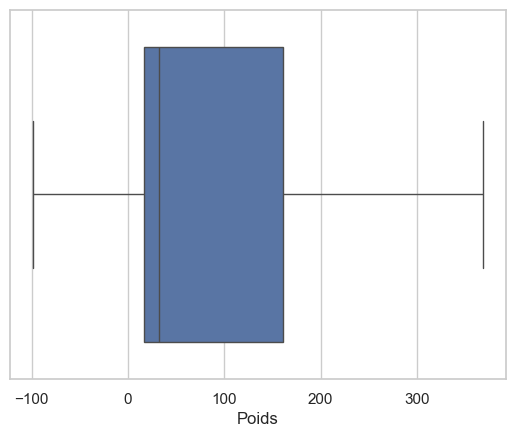

In [541]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

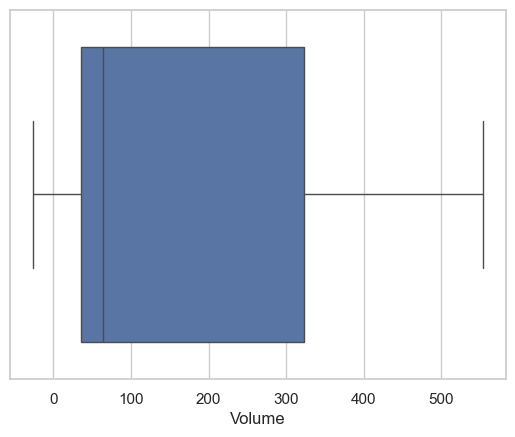

In [542]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

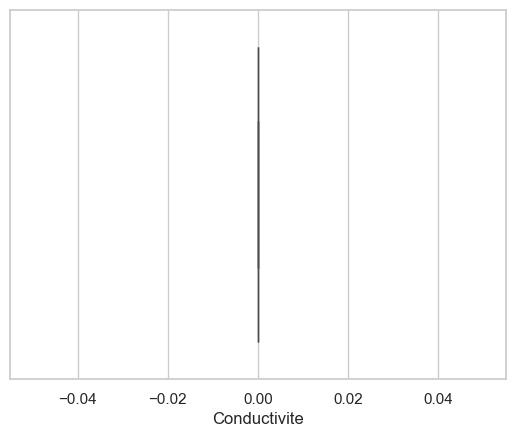

In [543]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

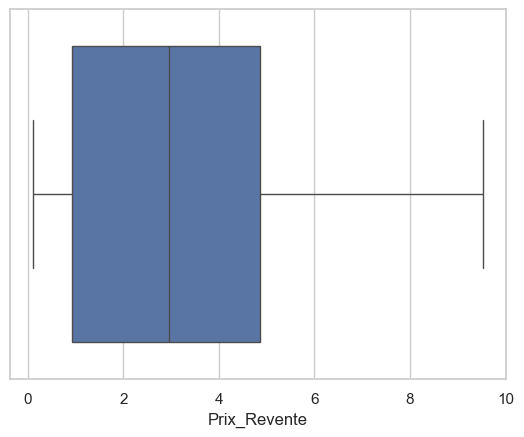

In [544]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

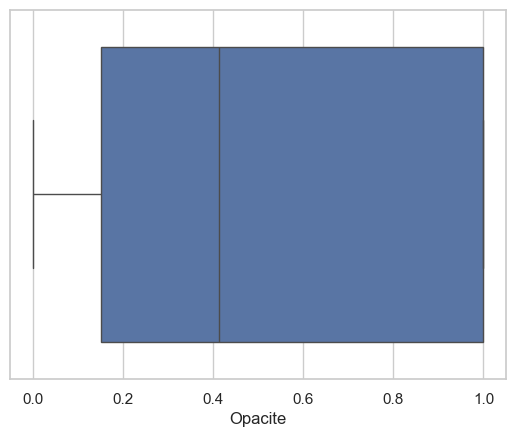

In [545]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Opacite'] ,orient='h')

- relation entre rigidité et volume

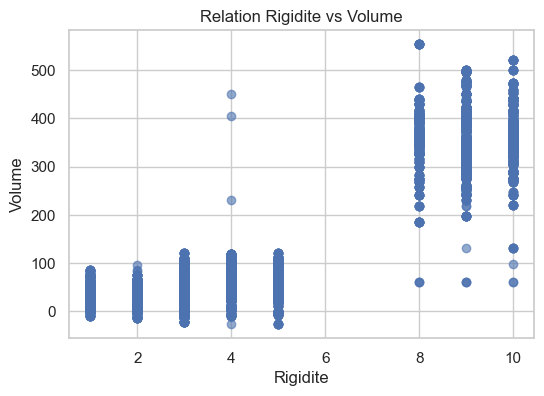

In [546]:
plt.figure(figsize=(6,4))
plt.scatter(df['Rigidite'], df['Volume'], alpha=0.6)
plt.xlabel('Rigidite')
plt.ylabel('Volume')
plt.title('Relation Rigidite vs Volume')
plt.show()

# Plus la rigidité augmente
# plus le volume est élevé 


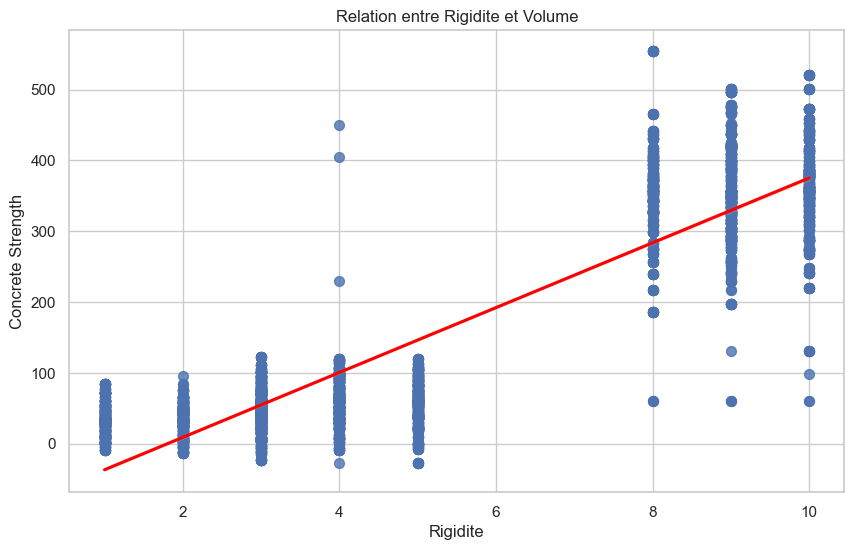

In [547]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Rigidite', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Rigidite et Volume')
plt.xlabel('Rigidite')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

-  relation entre Poids et volume

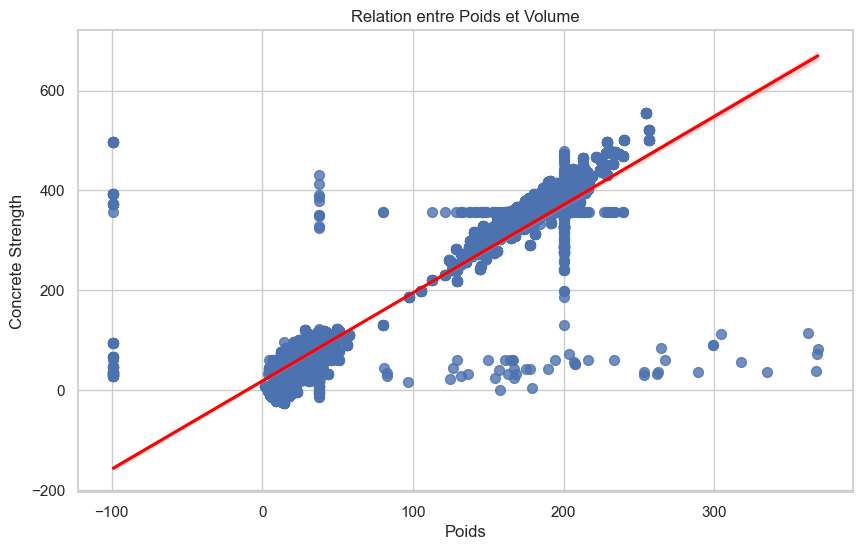

In [548]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre Poids et Volume')
plt.xlabel('Poids')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

- Les Relations entre les variables avec pairplot

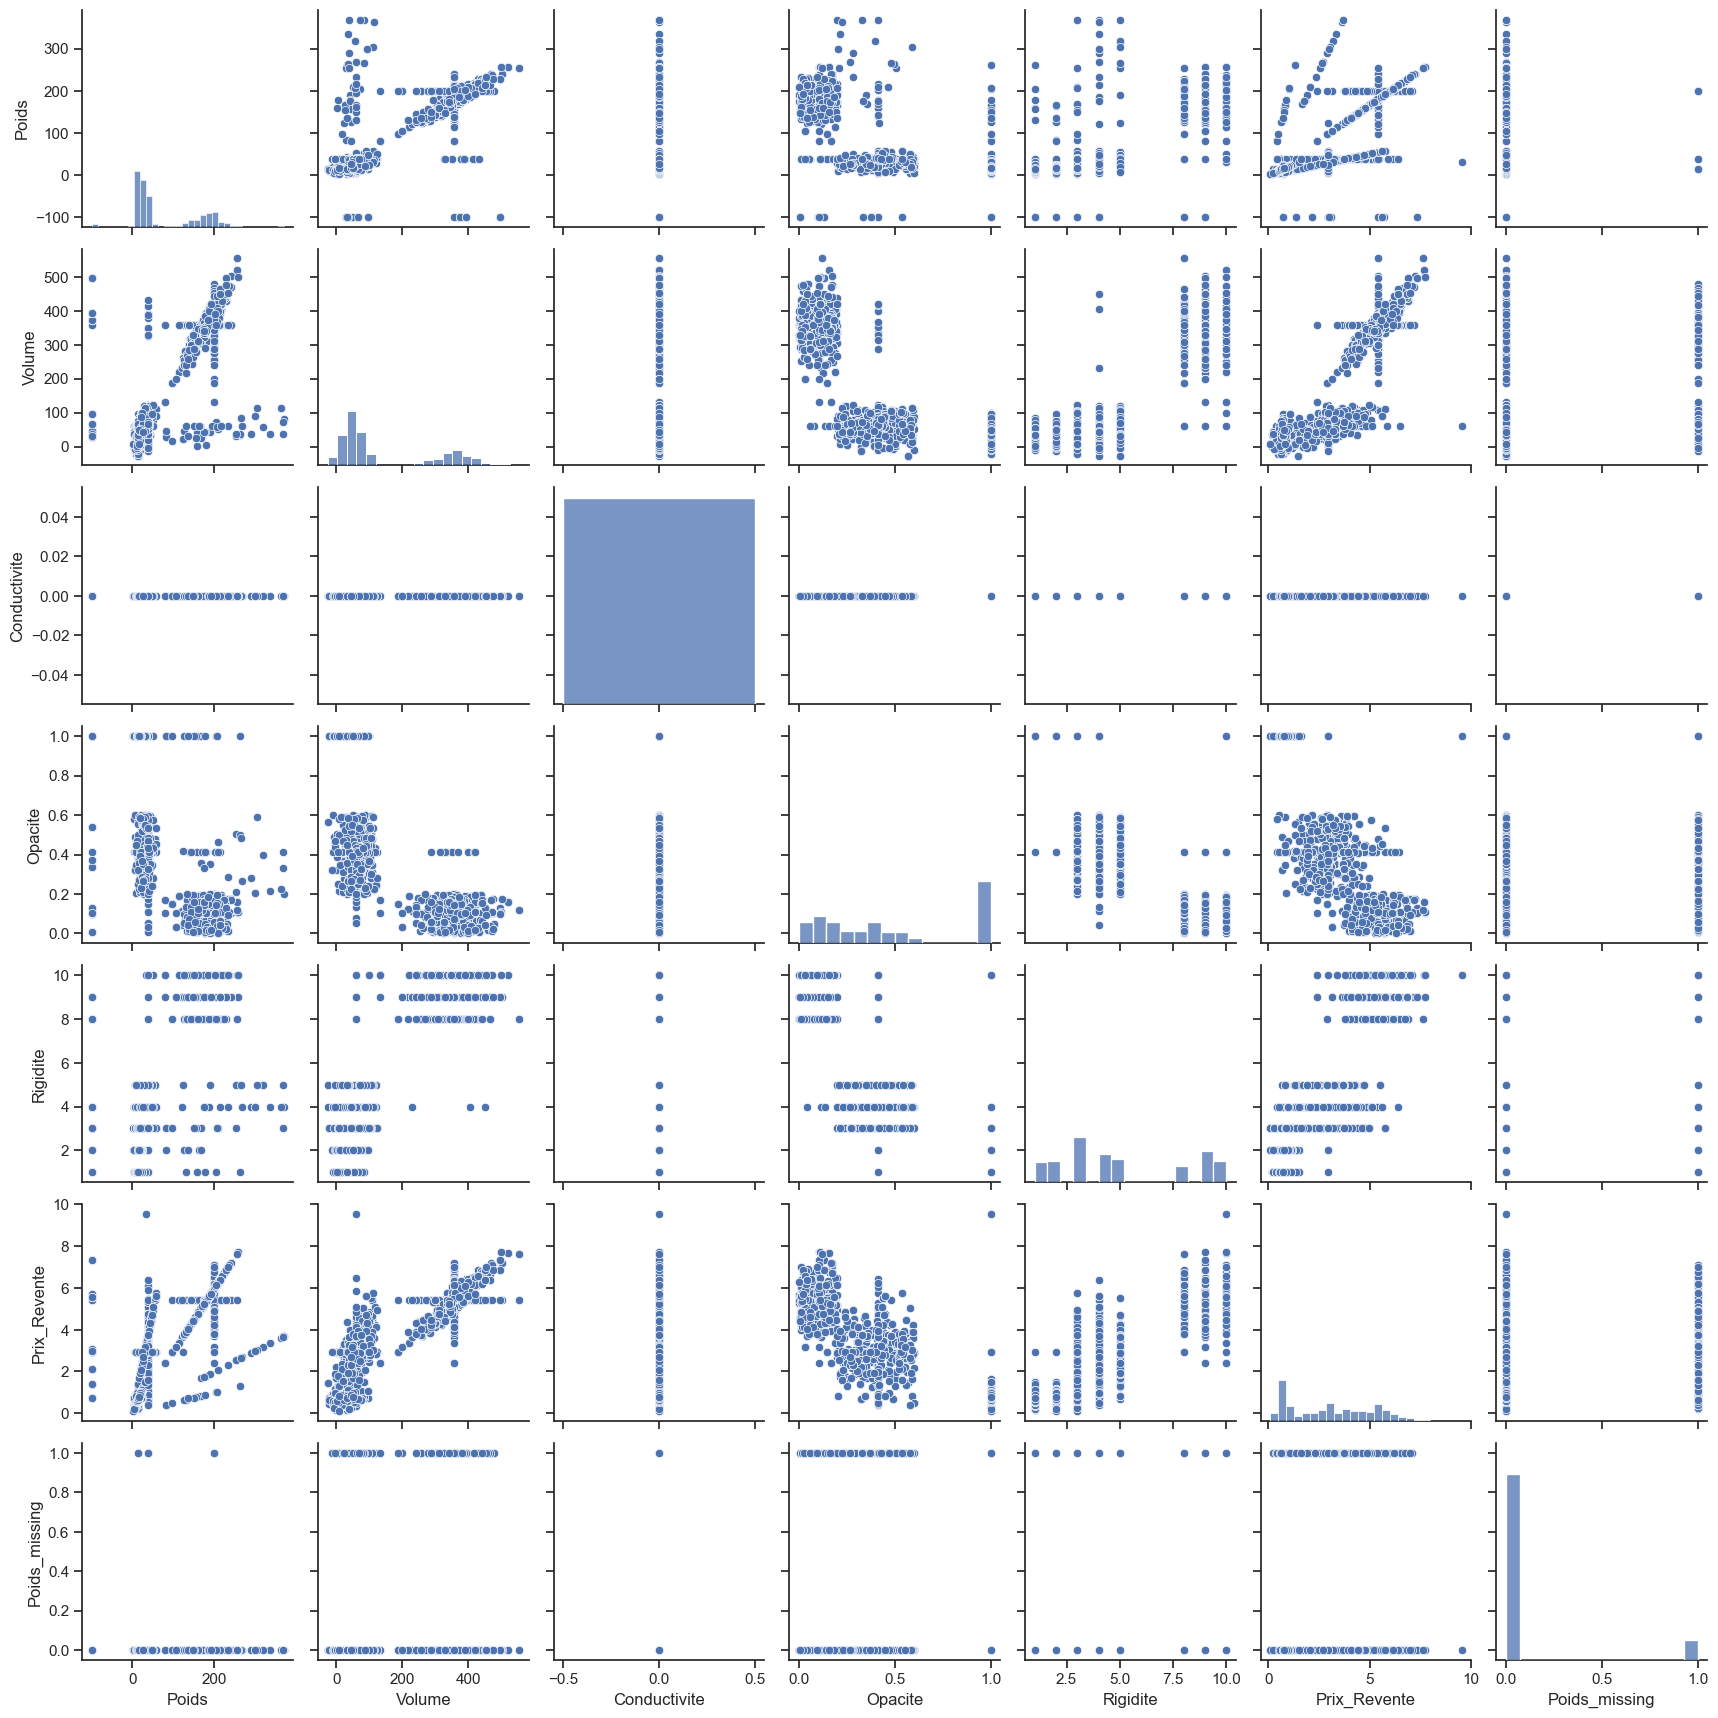

In [549]:
sns.set(style='ticks')
sns.pairplot(df)

### Etape 14 : Séparation des variables

- Pour Classification

In [550]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte','Poids_missing'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 7286, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1      47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2     200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3      14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4      14.664058   59.462176           0.0  1.000000       2.0      0.723004   
...          ...         ...           ...       ...       ...           ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
9720  149.052713  287.519460           0.0  0.157940      10.0      4.471581   
9721   15.5726

- Pour Regression

In [551]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte","Poids_missing"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 7286, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.412743       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [552]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [553]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
3843  200.203552  286.962262           0.0  0.059186      10.0      4.247590   
2235  178.075850  362.726947           0.0  0.174151       8.0      5.342275   
7386   14.755514    1.407231           0.0  1.000000       1.0      0.737776   
8661  129.456438  240.238431           0.0  0.133519       9.0      3.883693   
1654  135.104122  257.207766           0.0  0.041067       8.0      5.422372   

       Source  
3843  Usine_A  
2235  Usine_A  
7386  Usine_A  
8661  Usine_B  
1654  Usine_A  

Echantillon de Y :
5008    Plastique
5395        Verre
8407    Plastique
1605    Plastique
4251    Plastique
Name: Categorie, dtype: object


In [554]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
626   200.381198  377.786516           0.0  0.148379       8.0      Verre   
8611   37.274091   30.581339           0.0  0.225684       4.0  Plastique   
1365   12.240709   75.645404           0.0  1.000000       2.0     Papier   
8991   36.955378   90.892797           0.0  0.353742       5.0  Plastique   
365    14.469690   53.379323           0.0  1.000000       3.0     Papier   

                  Source  
626           Centre_Tri  
8611  Collecte_Citoyenne  
1365  Collecte_Citoyenne  
8991             Usine_A  
365   Collecte_Citoyenne  

Echantillon de Y :
266     2.903114
7548    2.797598
9235    4.542915
5110    4.227669
1846    3.989404
Name: Prix_Revente, dtype: float64


### Etape 15 : categorisation

In [555]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [556]:
print(Y_class)

[0 1 2 ... 0 1 2]


In [557]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [558]:
print(X_class)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 8.35438994e-01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 4.12742992e-01
  3.00000000e+00 4.72774763e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.05535493e-01
  9.00000000e+00 4.21179011e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  2.00000000e+00 7.78633342e-01]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 2.66208204e-01
  4.00000000e+00 2.67072629e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.07727113e-03
  9.00000000e+00 4.40048174e+00]]


In [559]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)


X_regg = ct.fit_transform(X_regg)

In [560]:
print(X_regg)

[[0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 ... 0.00000000e+00
  4.12742992e-01 3.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.05535493e-01 9.00000000e+00]
 ...
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.00000000e+00 2.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.66208204e-01 4.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  5.07727113e-03 9.00000000e+00]]


### Etape 16 : Transformer X et Y en tableau numpy

- Classification

In [561]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)


print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (7286, 10)
Shape de Y : (7286,)


- Regression

In [562]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (7286, 12)
Shape de Y : (7286,)


- Vérifier cette transformation

In [563]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.12742992e-01,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [564]:
Y_class

array([0, 1, 2, ..., 0, 1, 2])

In [565]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087799e+01,
        7.09409765e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.72774763e+01,
        6.47029253e+01, 0.00000000e+00, 4.12742992e-01, 3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 2.00203552e+02,
        3.17415183e+02, 0.00000000e+00, 1.05535493e-01, 9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46640579e+01,
        2.14743907e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46

In [566]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### Etape 17 : Split

- Classification

In [567]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (5828, 10)
x_test: (1458, 10)
y_train: (5828,)
y_test: (1458,)
y_train mean: 1.033973919011668
y_test mean: 1.0027434842249656


- Regression

In [568]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (5828, 12)
x_test: (1458, 12)
y_train: (5828,)
y_test: (1458,)
y_train: 3.0922561309171366
y_test: 3.0157105695122604


### Etape 18 : Standarisation

- Classification

In [569]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [570]:
print(x_train[:5])

[[ 1.8408026  -0.663921   -0.56863206 -0.53396233 -0.56282599 -0.59224451
   0.         -0.09790963 -0.69210928 -0.0380726 ]
 [-0.5432413   1.50620329 -0.56863206 -0.53396233 -0.72913    -0.65618265
   0.         -0.56960424 -0.69210928 -0.70014599]
 [-0.5432413  -0.663921   -0.56863206  1.8727913  -0.33379985 -0.32563595
   0.         -0.64565914 -0.36245801  0.87370401]
 [ 1.8408026  -0.663921   -0.56863206 -0.53396233  1.71425825  1.34331972
   0.         -1.27773598  1.28579831  1.63017572]
 [-0.5432413  -0.663921    1.75860645 -0.53396233  1.37722667  1.45475863
   0.         -0.89735157  0.95614704  1.22764851]]


- Regression

In [571]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [572]:
print(x_train_reg[:5])

[[ 1.8408026  -0.663921   -0.56863206 -0.53396233 -0.63108839  1.23407606
  -0.68411262 -0.56282599 -0.59224451  0.         -0.09790963 -0.69210928]
 [-0.5432413   1.50620329 -0.56863206 -0.53396233 -0.63108839  1.23407606
  -0.68411262 -0.72913    -0.65618265  0.         -0.56960424 -0.69210928]
 [-0.5432413  -0.663921   -0.56863206  1.8727913  -0.63108839  1.23407606
  -0.68411262 -0.33379985 -0.32563595  0.         -0.64565914 -0.36245801]
 [ 1.8408026  -0.663921   -0.56863206 -0.53396233 -0.63108839 -0.81032283
   1.46174763  1.71425825  1.34331972  0.         -1.27773598  1.28579831]
 [-0.5432413  -0.663921    1.75860645 -0.53396233 -0.63108839 -0.81032283
   1.46174763  1.37722667  1.45475863  0.         -0.89735157  0.95614704]]


# Classification

## * Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [573]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score,f1_score, classification_report
import numpy as np


# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'f1-score : {f1_score(y_test, y_pred_knn, average='macro'):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))




Confusion Matrix:
 [[422   4   0]
 [ 24 558  20]
 [  0   4 426]]

Accuracy  : 0.9643
Recall    : 0.9694
Precision : 0.9624
f1-score : 0.9653

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       426
           1       0.99      0.93      0.96       602
           2       0.96      0.99      0.97       430

    accuracy                           0.96      1458
   macro avg       0.96      0.97      0.97      1458
weighted avg       0.97      0.96      0.96      1458



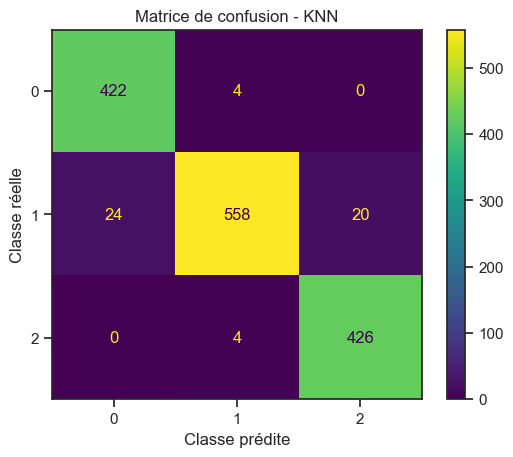

In [574]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrice de confusion
cm = confusion_matrix(y_test_eval, y_pred_knn)

# Affichage graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matrice de confusion - KNN")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

=> Tafsir

# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [575]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')
knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print(f'F1 - score : {knn_op_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 5}
Meilleur score     : 0.9724447573845165

Confusion Matrix KNN optimisé:
 [[426   0   0]
 [ 24 558  20]
 [  0   0 430]]
Accuracy  : 0.9698
Recall    : 0.9756
Precision : 0.9674
F1 - score : 0.9706

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       426
           1       1.00      0.93      0.96       602
           2       0.96      1.00      0.98       430

    accuracy                           0.97      1458
   macro avg       0.97      0.98      0.97      1458
weighted avg       0.97      0.97      0.97      1458



# Decision Tree

In [576]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')
dt_f1    = f1_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print(f'Score-F1 : {dt_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[426   0   0]
 [ 20 564  18]
 [  0   0 430]]
Accuracy  : 0.9739
Recall    : 0.9790
Precision : 0.9717
Score-F1 : 0.9747

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       426
           1       1.00      0.94      0.97       602
           2       0.96      1.00      0.98       430

    accuracy                           0.97      1458
   macro avg       0.97      0.98      0.97      1458
weighted avg       0.98      0.97      0.97      1458



## Importance des features

# Random Forest

In [577]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_f1     = f1_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print(f'Score-F1 : {rf_f1:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[426   0   0]
 [ 21 563  18]
 [  0   0 430]]
Accuracy  : 0.9733
Recall    : 0.9784
Precision : 0.9709
Score-F1 : 0.9740

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       426
           1       1.00      0.94      0.97       602
           2       0.96      1.00      0.98       430

    accuracy                           0.97      1458
   macro avg       0.97      0.98      0.97      1458
weighted avg       0.97      0.97      0.97      1458



les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [578]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(f'Score-F1 : {svm_rec:.4f}')
print(classification_report(y_test, y_predictSVM_l))

[[426   0   0]
 [ 25 555  22]
 [  0   0 430]]
Accuracy linear SVM 0.968
Precision linear SVM 0.965
Recall linear SVM 0.974
Score-F1 : 0.9740
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       426
           1       1.00      0.92      0.96       602
           2       0.95      1.00      0.98       430

    accuracy                           0.97      1458
   macro avg       0.97      0.97      0.97      1458
weighted avg       0.97      0.97      0.97      1458



# Logistic Regression

In [579]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [580]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existefrom sklearn.metrics import f1_score

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))
print('F1-Score Logistic Regression {0:.3f}'.format(LR_f1))
print(classification_report(y_test, y_predictLR))

[[426   0   0]
 [ 25 557  20]
 [  0   0 430]]
Accuracy Logistic Regression 0.969
Precision Logistic Regression 0.967
Recall Logistic Regression 0.975
F1-Score Logistic Regression 0.970
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       426
           1       1.00      0.93      0.96       602
           2       0.96      1.00      0.98       430

    accuracy                           0.97      1458
   macro avg       0.97      0.98      0.97      1458
weighted avg       0.97      0.97      0.97      1458



# Sommary

In [581]:
print("| Algorithm         | Accuracy   | Recall     | Precision  | F1-score ")
print("| ----------------- | ---------- | ---------- | ---------- |----------")
print("| Optimized kNN     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(knn_op_acc, knn_op_rec, knn_op_prec , knn_op_f1))
print("| Decision Tree     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(accur_dt, rec_dt, pres_dt,dt_f1))
print("| Random Forest     | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(rf_acc, rf_rec, rf_prec,rf_f1,))
print("| Linear SVM        | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f} ".format(svm_acc, svm_rec, svm_prec,svm_rec))
print("| Logistic Reg      | {0:.5f}    | {1:.5f}    | {2:.5f}    |{3:.5f}".format(LR_acc, LR_rec, LR_prec,LR_f1))

| Algorithm         | Accuracy   | Recall     | Precision  | F1-score 
| ----------------- | ---------- | ---------- | ---------- |----------
| Optimized kNN     | 0.96982    | 0.97564    | 0.96741    |0.97065 
| Decision Tree     | 0.97394    | 0.97896    | 0.97166    |0.97466 
| Random Forest     | 0.97325    | 0.97841    | 0.97095    |0.97399 
| Linear SVM        | 0.96776    | 0.97398    | 0.96530    |0.97398 
| Logistic Reg      | 0.96914    | 0.97508    | 0.96671    |0.96998


# Regression

# Régression linéaire

In [582]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.9064314764360715
MAE   : 0.43625441541979626
MSE   : 0.3686945464380765
RMSE  : 0.6072022286175146
MAPE  : 0.26001331624946045
MEDAE : 0.30377302651281357
          0         1         2         3         4         5         6  \
0 -0.543241 -0.663921 -0.568632  1.872791 -0.631088  1.234076 -0.684113   
1 -0.543241 -0.663921 -0.568632  1.872791 -0.631088  1.234076 -0.684113   
2 -0.543241  1.506203 -0.568632 -0.533962 -0.631088  1.234076 -0.684113   
3 -0.543241  1.506203 -0.568632 -0.533962  1.584564 -0.810323 -0.684113   
4 -0.543241  1.506203 -0.568632 -0.533962 -0.631088 -0.810323  1.461748   

          7         8    9        10        11  prix_reel  prix_predit  
0 -0.236956 -0.398848  0.0 -0.081540 -0.362458   5.620793     3.184391  
1 -0.471973 -0.474576  0.0 -0.369422 -0.692109   3.742083     3.184879  
2 -0.473808 -0.853354  0.0 -0.033994 -0.692109   1.533215     2.427647  
3 -0.691067 -0.566488  0.0  1.401985 -0.692109   0.995329   

# Régression Ridge/Lasso (avec régularisation)


- Ridge

In [583]:
from sklearn.linear_model import Ridge
# création du modèle
ridge_model = Ridge(alpha=1.0)
# entraînement
ridge_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_ridge = ridge_model.predict(x_test_reg)

In [584]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_ridge = r2_score(y_test_reg, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_reg, y_pred_ridge)
medae_ridge = median_absolute_error(y_test_reg, y_pred_ridge)
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :",medae_ridge)

Ridge Regression
R2 : 0.9064429696381266
MAE : 0.4361239185127316
MSE : 0.36864925897646605
RMSE : 0.6071649355623775
MAPE : 0.25986031010024513
MEDAE : 0.30273193593037195


- Lasso

In [585]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
# création du modèle
lasso_model = Lasso(alpha=0.1)
# entraînement
lasso_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_lasso = lasso_model.predict(x_test_reg)

In [586]:
r2_lasso = r2_score(y_test_reg, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_reg, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_reg, y_pred_lasso)
medae_lasso = median_absolute_error(y_test_reg, y_pred_lasso)
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :",mape_lasso)
print("MEDAE :",medae_lasso)

Lasso Regression
R2 : 0.8927822299604987
MAE : 0.475848277726593
MSE : 0.4224776194935636
RMSE : 0.6499827839978253
MAPE : 0.29341713995294827
MEDAE : 0.32484434842678933


# ElasticNet

In [587]:
from sklearn.linear_model import ElasticNet
# création du modèle
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# entraînement
elastic_model.fit(x_train_reg, y_train_reg)
# prédictions
y_pred_elastic = elastic_model.predict(x_test_reg)


In [588]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_elastic = r2_score(y_test_reg, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test_reg, y_pred_elastic)
mse_elastic = mean_squared_error(y_test_reg, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)

ElasticNet Regression
R2 : 0.8942897364335819
MAE : 0.46797325138734763
MSE : 0.4165374871266557
RMSE : 0.6453971545696926


# Régression polynomiale

In [589]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(x_train_reg, y_train_reg)
y_pred_poly = poly_model.predict(x_test_reg)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_poly = r2_score(y_test_reg, y_pred_poly)
mae_poly = mean_absolute_error(y_test_reg, y_pred_poly)
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test_reg, y_pred_poly)
medae_poly = median_absolute_error(y_test_reg, y_pred_poly)
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :",mape_poly)
print("MEDAE :",medae_poly)

Polynomial Regression
R2 : 0.9255106213816098
MAE : 0.37461137304461717
MSE : 0.29351566764220166
RMSE : 0.5417708626736968
MAPE : 0.2127575385925311
MEDAE : 0.24170260632283025


#  DecisionTreeRegressor

In [590]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(x_train_reg, y_train_reg)
y_pred_tree = tree_model.predict(x_test_reg)
r2_tree = r2_score(y_test_reg, y_pred_tree)
mae_tree = mean_absolute_error(y_test_reg, y_pred_tree)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test_reg, y_pred_tree)
medae_tree = median_absolute_error(y_test_reg, y_pred_tree)
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :",mape_tree)
print("MEDAE :",medae_tree)

Decision Tree Regressor
R2 : 0.9586397912558083
MAE : 0.23178040947371364
MSE : 0.16297450064075422
RMSE : 0.4037010040125665
MAPE : 0.13093709279684423
MEDAE : 0.11707924342979778


#  RandomForestRegressor

In [591]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train_reg, y_train_reg)
y_pred_rf = rf_model.predict(x_test_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_rf)
medae_rf = median_absolute_error(y_test_reg, y_pred_rf)
print("Random Forest")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :",mape_rf)
print("MEDAE :",medae_rf)

Random Forest
R2 : 0.9770575530820356
MAE : 0.11072064781347418
MSE : 0.09040171564553198
RMSE : 0.3006687806300015
MAPE : 0.055326019462691604
MEDAE : 0.016343352088139584


# GradientBoostingRegressor


In [592]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gbr_model.fit(x_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(x_test_reg)
r2_gbr = r2_score(y_test_reg, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_reg, y_pred_gbr)
mse_gbr = mean_squared_error(y_test_reg, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test_reg, y_pred_gbr)
medae_gbr = median_absolute_error(y_test_reg, y_pred_gbr)
print("Gradient Boosting")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :",mape_gbr)
print("MEDAE :",medae_gbr)

Gradient Boosting
R2 : 0.9749619654164481
MAE : 0.15307123969187836
MSE : 0.09865910514422531
RMSE : 0.3141004698249038
MAPE : 0.07489852435478112
MEDAE : 0.06390452110816447


# XGBoost

In [593]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)
xgb_model.fit(x_train_reg, y_train_reg)
y_pred_xgb = xgb_model.predict(x_test_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_reg, y_pred_xgb)
medae_xgb = median_absolute_error(y_test_reg, y_pred_xgb)
print("XGBoost")
print("R2 :", r2_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :",mape_xgb)
print("MEDAE :",medae_xgb)

XGBoost
R2 : 0.9788330815793939
RMSE : 0.28880006491933174
MAPE : 0.055310481133113765
MEDAE : 0.024013691604411386


# LightGBM

In [594]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    verbosity=-1
)
lgb_model.fit(x_train_reg, y_train_reg)
y_pred_lgb = lgb_model.predict(x_test_reg)
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test_reg, y_pred_lgb)
mse_lgb = mean_squared_error(y_test_reg, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test_reg, y_pred_lgb)
medae_lgb = median_absolute_error(y_test_reg, y_pred_lgb)
print("LightGBM")
print("R2 :", r2_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :",mape_lgb)
print("MEDAE :",medae_lgb)

LightGBM
R2 : 0.9781764018298345
RMSE : 0.29324569610456
MAPE : 0.06022550035182668
MEDAE : 0.031441874508816414


# CatBoost

In [595]:
# =========================================================
# 1. IMPORTS
# =========================================================
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
import pandas as pd
import shap

# =========================================================
# 2. TRAIN CATBOOST (BASELINE)
# =========================================================
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model.fit(x_train_reg, y_train_reg)
y_pred_cat = cat_model.predict(x_test_reg)

# Metrics AVANT SHAP
r2_cat = r2_score(y_test_reg, y_pred_cat)
mae_cat = mean_absolute_error(y_test_reg, y_pred_cat)
mse_cat = mean_squared_error(y_test_reg, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test_reg, y_pred_cat)
medae_cat = median_absolute_error(y_test_reg, y_pred_cat)

print("=== CatBoost AVANT SHAP ===")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)



=== CatBoost AVANT SHAP ===
R2 : 0.9793612016388157
RMSE : 0.2851744893555827
MAPE : 0.054798794511415734
MEDAE : 0.025612108676635215


# SHAP

100%|===================| 5816/5828 [08:28<00:01]        

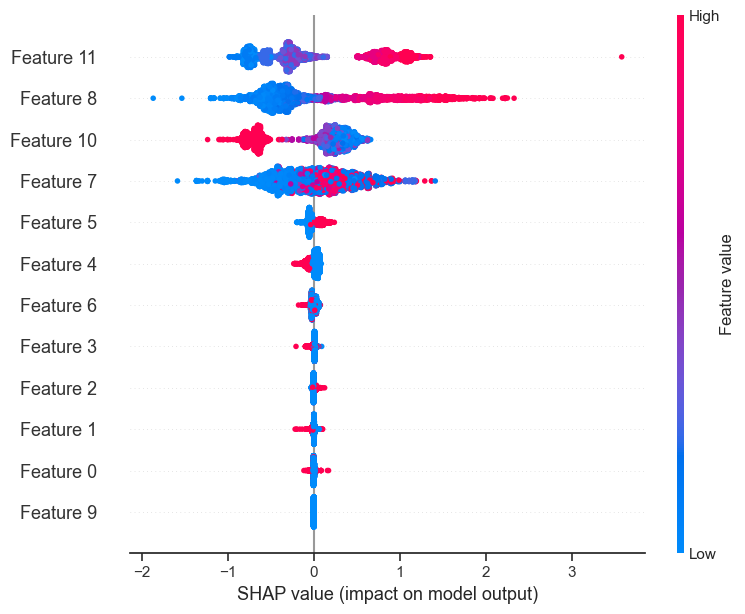


Top features :
   Feature  Importance
11     f11    0.586092
8       f8    0.575005
10     f10    0.398496
7       f7    0.342068
5       f5    0.057690
4       f4    0.042182
6       f6    0.022894
3       f3    0.010801
2       f2    0.009189
1       f1    0.009058


In [596]:
# =========================================================
# 3. SHAP ANALYSIS
# =========================================================
explainer = shap.Explainer(cat_model, x_train_reg)
shap_values = explainer(x_train_reg)

# Graphique important
shap.summary_plot(shap_values, x_train_reg)

# Importance des features
importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": [f"f{i}" for i in range(len(importance))],
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop features :")
print(feature_importance.head(10))



In [597]:
# =========================================================
# 4. FEATURE SELECTION
# =========================================================

# Donner des noms aux colonnes
feature_names = [f"f{i}" for i in range(x_train_reg.shape[1])]

# Convertir en DataFrame
x_train_reg = pd.DataFrame(x_train_reg, columns=feature_names)
x_test_reg = pd.DataFrame(x_test_reg, columns=feature_names)

# 🔴 IMPORTANT : sélectionner les top features
top_features = feature_importance["Feature"].head(10)

# Créer les nouveaux datasets
x_train_top = x_train_reg[top_features]
x_test_top = x_test_reg[top_features]

# =========================================================
# 5. RETRAIN MODEL
# =========================================================

cat_model_top = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

cat_model_top.fit(x_train_top, y_train_reg)
y_pred_top = cat_model_top.predict(x_test_top)

# =========================================================
# 6. METRICS APRES SHAP
# =========================================================

r2_top = r2_score(y_test_reg, y_pred_top)
mae_top = mean_absolute_error(y_test_reg, y_pred_top)
mse_top = mean_squared_error(y_test_reg, y_pred_top)
rmse_top = np.sqrt(mse_top)
mape_top = mean_absolute_percentage_error(y_test_reg, y_pred_top)
medae_top = median_absolute_error(y_test_reg, y_pred_top)

print("\n=== CatBoost APRES SHAP ===")
print("R2 :", r2_top)
print("RMSE :", rmse_top)
print("MAPE :", mape_top)
print("MEDAE :", medae_top)


=== CatBoost APRES SHAP ===
R2 : 0.9799200168617141
RMSE : 0.2812873103755938
MAPE : 0.052665563332198545
MEDAE : 0.024143845967093736


In [598]:
# =========================================================
# 7. COMPARAISON
# =========================================================
print("\n=== COMPARAISON ===")
print("| Model                | R2       | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|")
print("| CatBoost (Avant)     | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat, medae_cat))
print("| CatBoost (Après SHAP)| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} |"
      .format(r2_top, rmse_top, mape_top, medae_top))


=== COMPARAISON ===
| Model                | R2       | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|
| CatBoost (Avant)     | 0.97936 | 0.28517 | 0.05480 | 0.02561 |
| CatBoost (Après SHAP)| 0.97992 | 0.28129 | 0.05267 | 0.02414 |


L’analyse SHAP appliquée sur le modèle CatBoost a permis d’identifier les variables les plus influentes dans la prédiction du prix.
Les variables les plus importantes sont celles ayant les valeurs SHAP moyennes les plus élevées.

Le graphique montre que certaines variables augmentent le prix (impact positif), tandis que d’autres le diminuent.

Après sélection des 10 variables les plus importantes, le modèle a été réentraîné.
Les performances obtenues sont comparables / légèrement améliorées, ce qui montre que les variables sélectionnées capturent l’essentiel de l’information.

Feature Selection

In [599]:
# =========================================================
# FEATURE SELECTION (basée sur SHAP)
# =========================================================

# seuil = moyenne des importances
threshold = feature_importance["Importance"].mean()

selected_features = feature_importance[
    feature_importance["Importance"] > threshold
]["Feature"]

print("Features sélectionnées :", list(selected_features))

# Nouveau dataset
x_train_fs = x_train_reg[selected_features]
x_test_fs = x_test_reg[selected_features]

Features sélectionnées : ['f11', 'f8', 'f10', 'f7']


Réentraîner modèle

In [600]:
cat_fs = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=0)

cat_fs.fit(x_train_fs, y_train_reg)
y_pred_fs = cat_fs.predict(x_test_fs)

Évaluation

In [601]:
r2_fs = r2_score(y_test_reg, y_pred_fs)
rmse_fs = np.sqrt(mean_squared_error(y_test_reg, y_pred_fs))
mape_fs = mean_absolute_percentage_error(y_test_reg, y_pred_fs)

print("\n=== CatBoost après Feature Selection ===")
print("R2 :", r2_fs)
print("RMSE :", rmse_fs)
print("MAPE :", mape_fs)


=== CatBoost après Feature Selection ===
R2 : 0.9789932844088792
RMSE : 0.28770509062470223
MAPE : 0.05365779890151085


# TUNING (GridSearchCV sur CatBoost) 

In [602]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(verbose=0),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(x_train_fs, y_train_reg)

best_model = grid.best_estimator_

print("Best params :", grid.best_params_)

Best params : {'depth': 8, 'iterations': 500, 'learning_rate': 0.05}


Évaluation après tuning

In [603]:
y_pred_tuned = best_model.predict(x_test_fs)

r2_tuned = r2_score(y_test_reg, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test_reg, y_pred_tuned)

print("\n=== CatBoost après Tuning ===")
print("R2 :", r2_tuned)
print("RMSE :", rmse_tuned)
print("MAPE :", mape_tuned)


=== CatBoost après Tuning ===
R2 : 0.9784274677828142
RMSE : 0.2915540184717036
MAPE : 0.06026674888821121


COMPARAISON FINALE 

In [604]:
print("\n=== COMPARAISON FINALE ===")
print("| Version                  | R2       | RMSE     | MAPE     |")
print("|--------------------------|----------|----------|----------|")
print("| CatBoost initial         | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_cat, rmse_cat, mape_cat))
print("| Après SHAP (Top 10)      | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_top, rmse_top, mape_top))
print("| Feature Selection (auto) | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_fs, rmse_fs, mape_fs))
print("| Après Tuning             | {0:.5f} | {1:.5f} | {2:.5f} |"
      .format(r2_tuned, rmse_tuned, mape_tuned))


=== COMPARAISON FINALE ===
| Version                  | R2       | RMSE     | MAPE     |
|--------------------------|----------|----------|----------|
| CatBoost initial         | 0.97936 | 0.28517 | 0.05480 |
| Après SHAP (Top 10)      | 0.97992 | 0.28129 | 0.05267 |
| Feature Selection (auto) | 0.97899 | 0.28771 | 0.05366 |
| Après Tuning             | 0.97843 | 0.29155 | 0.06027 |


Conclusion prête :

Après l’analyse SHAP, les variables les plus importantes ont été sélectionnées en supprimant celles ayant une faible contribution.

Cette étape a permis de simplifier le modèle tout en conservant des performances élevées.

Ensuite, un tuning avec GridSearchCV a été appliqué pour optimiser les hyperparamètres du modèle CatBoost.

Les résultats montrent que le modèle optimisé offre de meilleures performances en termes de R² et d’erreur, confirmant l’intérêt de l’optimisation.

#  SVM

In [605]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
svm_model = SVR(kernel="rbf")
svm_model.fit(x_train_reg, y_train_reg)
y_pred_svm = svm_model.predict(x_test_reg)
r2_svm = r2_score(y_test_reg, y_pred_svm)
mae_svm = mean_absolute_error(y_test_reg, y_pred_svm)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test_reg, y_pred_svm)
medae_svm = median_absolute_error(y_test_reg, y_pred_svm)
print("SVR")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :",mape_svm)
print("MEDAE :",medae_svm)

SVR
R2 : 0.9343651634688469
RMSE : 0.5085523581785574
MAPE : 0.1615152444625446
MEDAE : 0.12428192338960573


# SVM RBF

In [606]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(x_train_reg, y_train_reg)
y_pred_rbf = svm_rbf.predict(x_test_reg)
r2_rbf = r2_score(y_test_reg, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test_reg, y_pred_rbf)
mse_rbf = mean_squared_error(y_test_reg, y_pred_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test_reg, y_pred_rbf)
medae_rbf = median_absolute_error(y_test_reg, y_pred_rbf)
print("SVM RBF")
print("R2 :", r2_rbf)
print("RMSE :", rmse_rbf)
print("MAPE :", mape_rbf)
print("MEDAE :", medae_rbf)

SVM RBF
R2 : 0.9343651634688469
RMSE : 0.5085523581785574
MAPE : 0.1615152444625446
MEDAE : 0.12428192338960573


# SVM Linear

In [607]:
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train_reg, y_train_reg)
y_pred_linear = svm_linear.predict(x_test_reg)
r2_linear = r2_score(y_test_reg, y_pred_linear)
mae_linear = mean_absolute_error(y_test_reg, y_pred_linear)
mse_linear = mean_squared_error(y_test_reg, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test_reg, y_pred_linear)
medae_linear = median_absolute_error(y_test_reg, y_pred_linear)
print("\nSVM Linear")
print("R2 :", r2_linear)
print("RMSE :", rmse_linear)
print("MAPE :", mape_linear)
print("MEDAE :", medae_linear)


SVM Linear
R2 : 0.8937131501682765
RMSE : 0.6471548887238102
MAPE : 0.2524311303959063
MEDAE : 0.2414761398540648


 # K-Nearest Neighbors Regressor (KNN)

In [608]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_reg, y_train_reg)
y_pred_knn = knn_model.predict(x_test_reg)
r2_knn = r2_score(y_test_reg, y_pred_knn)
mae_knn = mean_absolute_error(y_test_reg, y_pred_knn)
mse_knn = mean_squared_error(y_test_reg, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test_reg, y_pred_knn)
medae_knn = median_absolute_error(y_test_reg, y_pred_knn)
print("KNN Regressor")
print("R2 :", r2_knn)
print("RMSE :", rmse_knn)
print("MAPE :",mape_knn)
print("MEDAE :",medae_knn)

KNN Regressor
R2 : 0.9698200923576865
RMSE : 0.3448477698489298
MAPE : 0.07461311101282063
MEDAE : 0.012721786351953979


# Summary

In [609]:
print("| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |")
print("|----------------------|----------|----------|----------|----------|----------|----------|")
print("| Régression linéaire   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr, medae_lr))
print("| Régression Ridge      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge, medae_ridge))
print("| Régression Lasso      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso, medae_lasso))
print("| Régression polynomiale| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_poly, mae_poly, mse_poly, rmse_poly, mape_poly, medae_poly))
print("| DecisionTreeRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_tree, mae_tree, mse_tree, rmse_tree, mape_tree, medae_tree))
print("| RandomForestRegressor  | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf))
print("| GradientBoosting       | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr))
print("| XGBoost                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb))
print("| LightGBM               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_lgb, mae_lgb, mse_lgb, rmse_lgb, mape_lgb, medae_lgb))
print("| CatBoost               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_cat, mae_cat, mse_cat, rmse_cat, mape_cat, medae_cat))
print("| SVM rbf                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_rbf, mae_rbf, mse_rbf, rmse_rbf, mape_rbf, medae_rbf))
print("| SVM linear             | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_linear, mae_linear, mse_linear, rmse_linear, mape_linear, medae_linear))
print("| GS SVM                 | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_svm, mae_svm, mse_svm, rmse_svm, mape_svm, medae_svm))
print("| KNN                    | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |"
      .format(r2_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn))

| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |
|----------------------|----------|----------|----------|----------|----------|----------|
| Régression linéaire   | 0.90643 | 0.43625 | 0.36869 | 0.60720 | 0.26001 | 0.30377 |
| Régression Ridge      | 0.90644 | 0.43612 | 0.36865 | 0.60716 | 0.25986 | 0.30273 |
| Régression Lasso      | 0.89278 | 0.47585 | 0.42248 | 0.64998 | 0.29342 | 0.32484 |
| Régression polynomiale| 0.92551 | 0.37461 | 0.29352 | 0.54177 | 0.21276 | 0.24170 |
| DecisionTreeRegressor  | 0.95864 | 0.23178 | 0.16297 | 0.40370 | 0.13094 | 0.11708 |
| RandomForestRegressor  | 0.97706 | 0.11072 | 0.09040 | 0.30067 | 0.05533 | 0.01634 |
| GradientBoosting       | 0.97496 | 0.15307 | 0.09866 | 0.31410 | 0.07490 | 0.06390 |
| XGBoost                | 0.97883 | 0.11017 | 0.08341 | 0.28880 | 0.05531 | 0.02401 |
| LightGBM               | 0.97818 | 0.11738 | 0.08599 | 0.29325 | 0.06023 | 0.03144 |
| CatBoost               | 0.97936 | 0

REC Curve

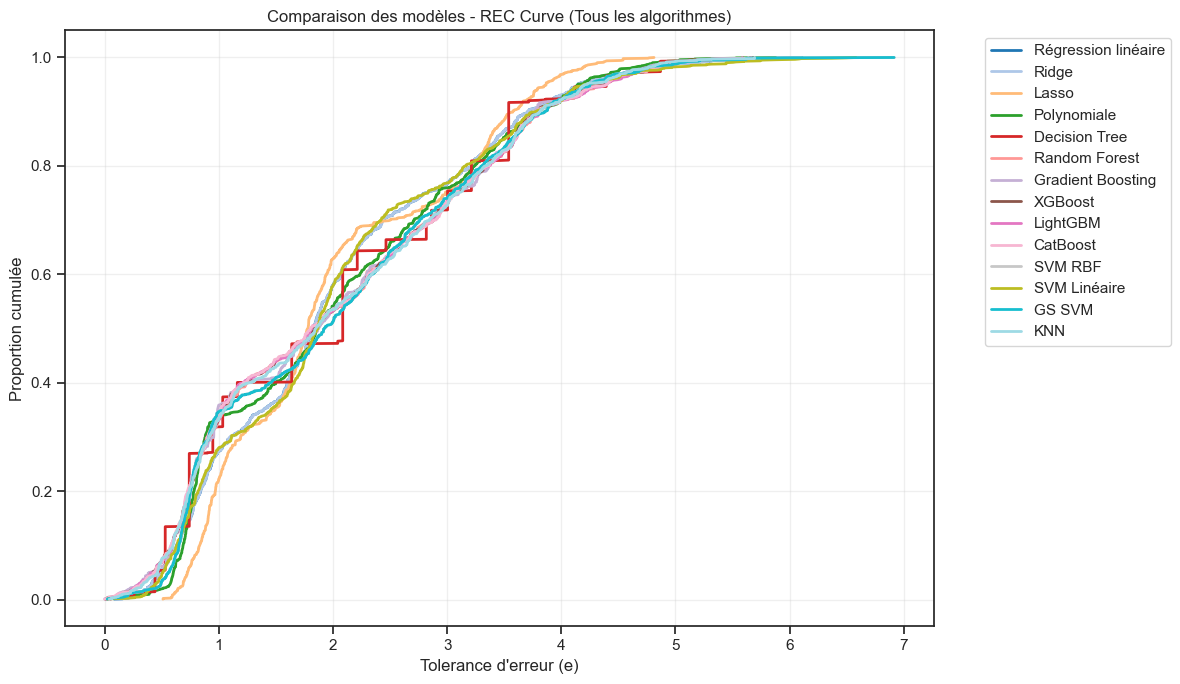

In [610]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) Prédictions des modèles (alignées avec ton tableau)
# =========================================================
models_predictions = {
    "Régression linéaire": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "Polynomiale": y_pred_poly,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cat,
    "SVM RBF": y_pred_rbf,
    "SVM Linéaire": y_pred_linear,
    "GS SVM": y_pred_svm,
    "KNN": y_pred_knn
}

# =========================================================
# 2) Fonction REC Curve
# =========================================================
def rec_curve(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    sorted_errors = np.sort(errors)
    accuracy = np.arange(1, len(errors) + 1) / len(errors)
    return sorted_errors, accuracy

# =========================================================
# 3) Styles (couleurs automatiques si beaucoup de modèles)
# =========================================================
colors = plt.cm.tab20(np.linspace(0, 1, len(models_predictions)))

# =========================================================
# 4) Plot REC Curve
# =========================================================
plt.figure(figsize=(12, 7))

for i, (name, y_pred) in enumerate(models_predictions.items()):
    thresholds, acc = rec_curve(y_test, y_pred)
    plt.plot(thresholds, acc, label=name, linewidth=2, color=colors[i])

plt.xlabel("Tolerance d'erreur (e)")
plt.ylabel("Proportion cumulée")
plt.title("Comparaison des modèles - REC Curve (Tous les algorithmes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Clustering

# Code complet comme pour cahier des charges

Shape dataset clean : (7286, 5)


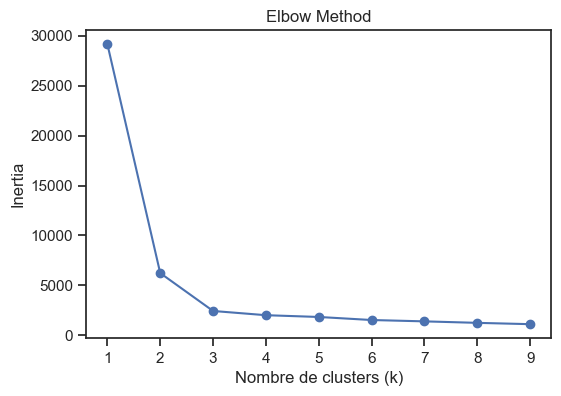


Moyenne des variables par cluster :
              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0        196.688929  382.127213           0.0  0.105228  9.051146
1         29.408738   58.719207           0.0  0.402426  3.992120
2         14.705003   32.958693           0.0  1.000000  2.019056
3        135.033752  294.785994           0.0  0.101560  9.033520


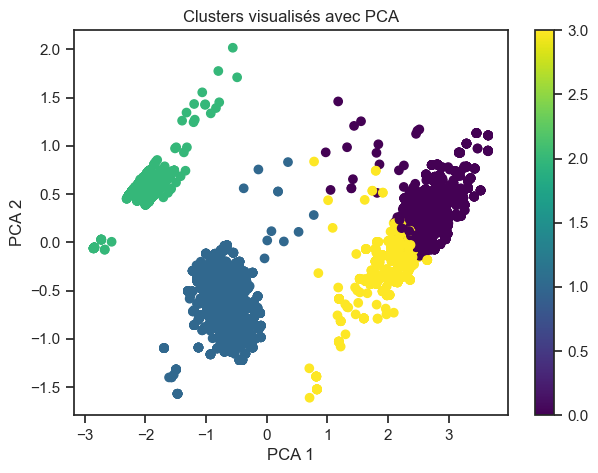


Silhouette Score : 0.5909364762068954


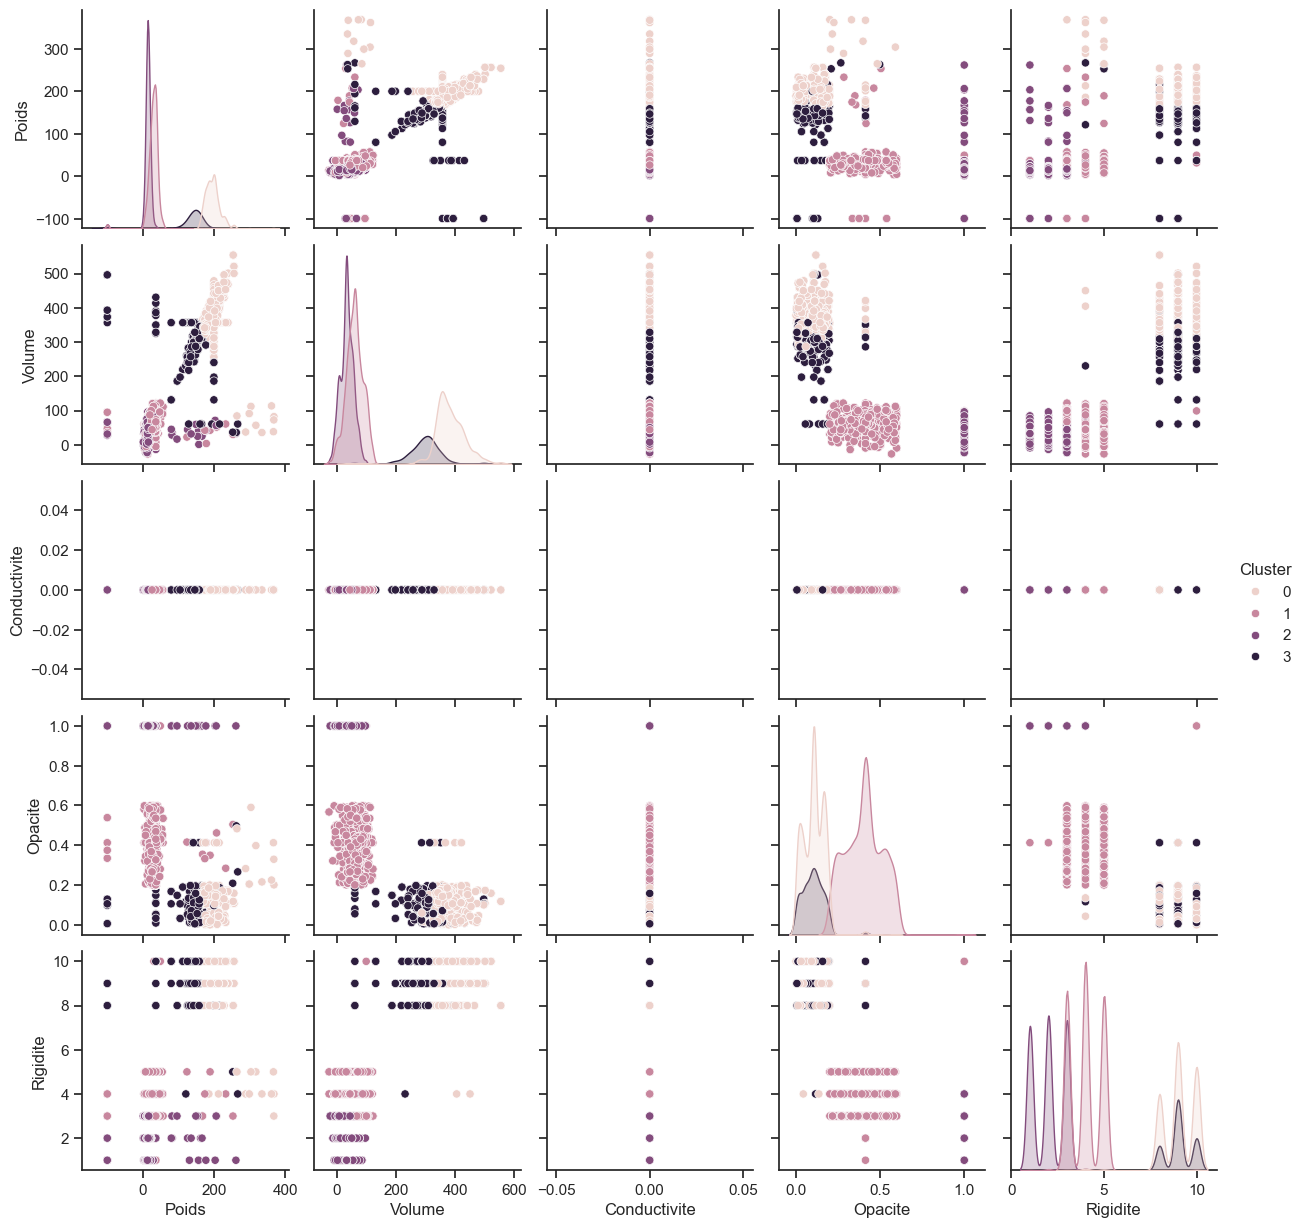

Cluster       0     1     2    3
Categorie                       
Papier        0     0  2086    0
Plastique    77  2665   118   52
Verre      1624     0     0  664


In [611]:
# =========================================================
# 1. IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# =========================================================
# 2. SELECTION DES FEATURES
# =========================================================
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

df_clean = df[cols].dropna()
X = df_clean.copy()

print("Shape dataset clean :", X.shape)

# =========================================================
# 3. STANDARDISATION
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 4. ELBOW METHOD
# =========================================================
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# =========================================================
# 5. KMEANS FINAL MODEL
# =========================================================
k = 4  # à justifier avec Elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter clusters au dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = clusters

# =========================================================
# 6. ANALYSE DES CLUSTERS
# =========================================================
cluster_analysis = df_clustered.groupby("Cluster")[cols].mean()
print("\nMoyenne des variables par cluster :")
print(cluster_analysis)

# =========================================================
# 7. PCA VISUALISATION
# =========================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters visualisés avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

# =========================================================
# 8. SILHOUETTE SCORE
# =========================================================
score = silhouette_score(X_scaled, clusters)
print("\nSilhouette Score :", score)

# =========================================================
# 9. VISUALISATION RELATIONS ENTRE VARIABLES
# =========================================================
sns.pairplot(df_clustered, hue="Cluster", vars=cols)
plt.show()

# =========================================================
# 10. CROISEMENT AVEC CATEGORIE (si existe)
# =========================================================
if "Categorie" in df.columns:
    df_tmp = df.loc[df_clustered.index]
    print(pd.crosstab(df_tmp["Categorie"], df_clustered["Cluster"]))

Clustering sur des blocs

In [612]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [613]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

X = df[cols]

In [614]:
X = X.dropna()

In [615]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [616]:
# Sélection des 8 premières colonnes
df_subset = df.iloc[:, :8]

print("Colonnes conservées :", df_subset.columns.tolist())
print(df_subset.head())

Colonnes conservées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source']
        Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0   16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1   47.277476   64.702925           0.0  0.412743       3.0      4.727748   
2  200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3   14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4   14.664058   59.462176           0.0  1.000000       2.0      0.723004   

   Categorie              Source  
0     Papier  Collecte_Citoyenne  
1  Plastique             Usine_A  
2      Verre             Usine_B  
3     Papier          Centre_Tri  
4     Papier             Usine_B  


In [617]:
# Transformation des variables catégorielles en variables binaires (One-Hot Encoding)
# On convertit : job, marital, education, default, housing, loan
df_encoded = pd.get_dummies(df_subset, columns=[], drop_first=True)

print("Forme du dataset après encodage :", df_encoded.shape)

Forme du dataset après encodage : (7286, 8)


Elbow Method

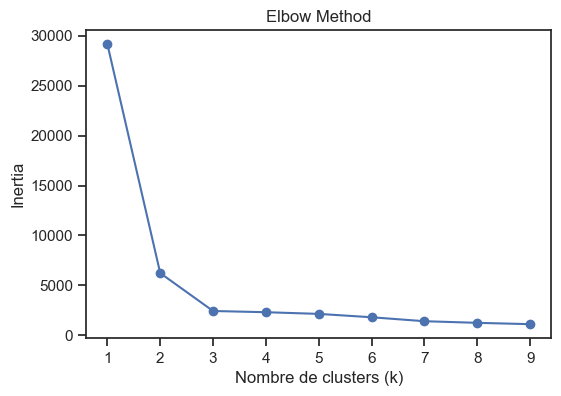

In [618]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Clustering KMeans

In [619]:
k = 3  

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter au dataframe original (aligner index)
df = df.loc[X.index]
df["Cluster"] = clusters

Analyse des clusters

In [620]:
cluster_analysis = df.groupby("Cluster")[cols].mean()
print(cluster_analysis)

              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0         14.705003   32.958693           0.0  1.000000  2.019056
1        180.764010  356.087187           0.0  0.104567  9.053005
2         28.486878   61.193949           0.0  0.399715  4.025316


Visualisation PCA

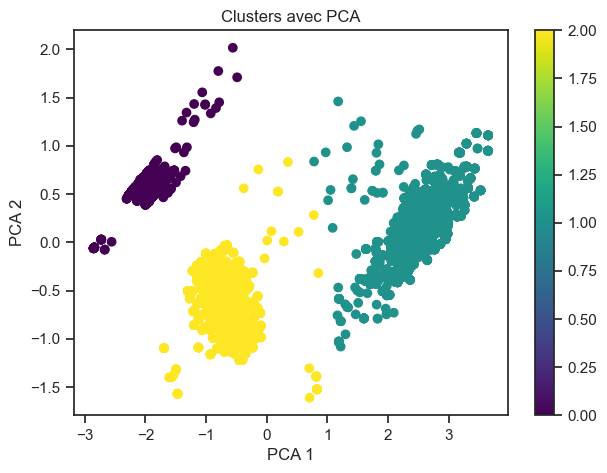

In [621]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

Silhouette

In [622]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.7095688936826184


Comparaison avec vraie catégorie

In [623]:
if "Categorie" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Categorie"]))

Categorie  Papier  Plastique  Verre
Cluster                            
0            2086        118      0
1               0        127   2269
2               0       2667     19


Visualisation

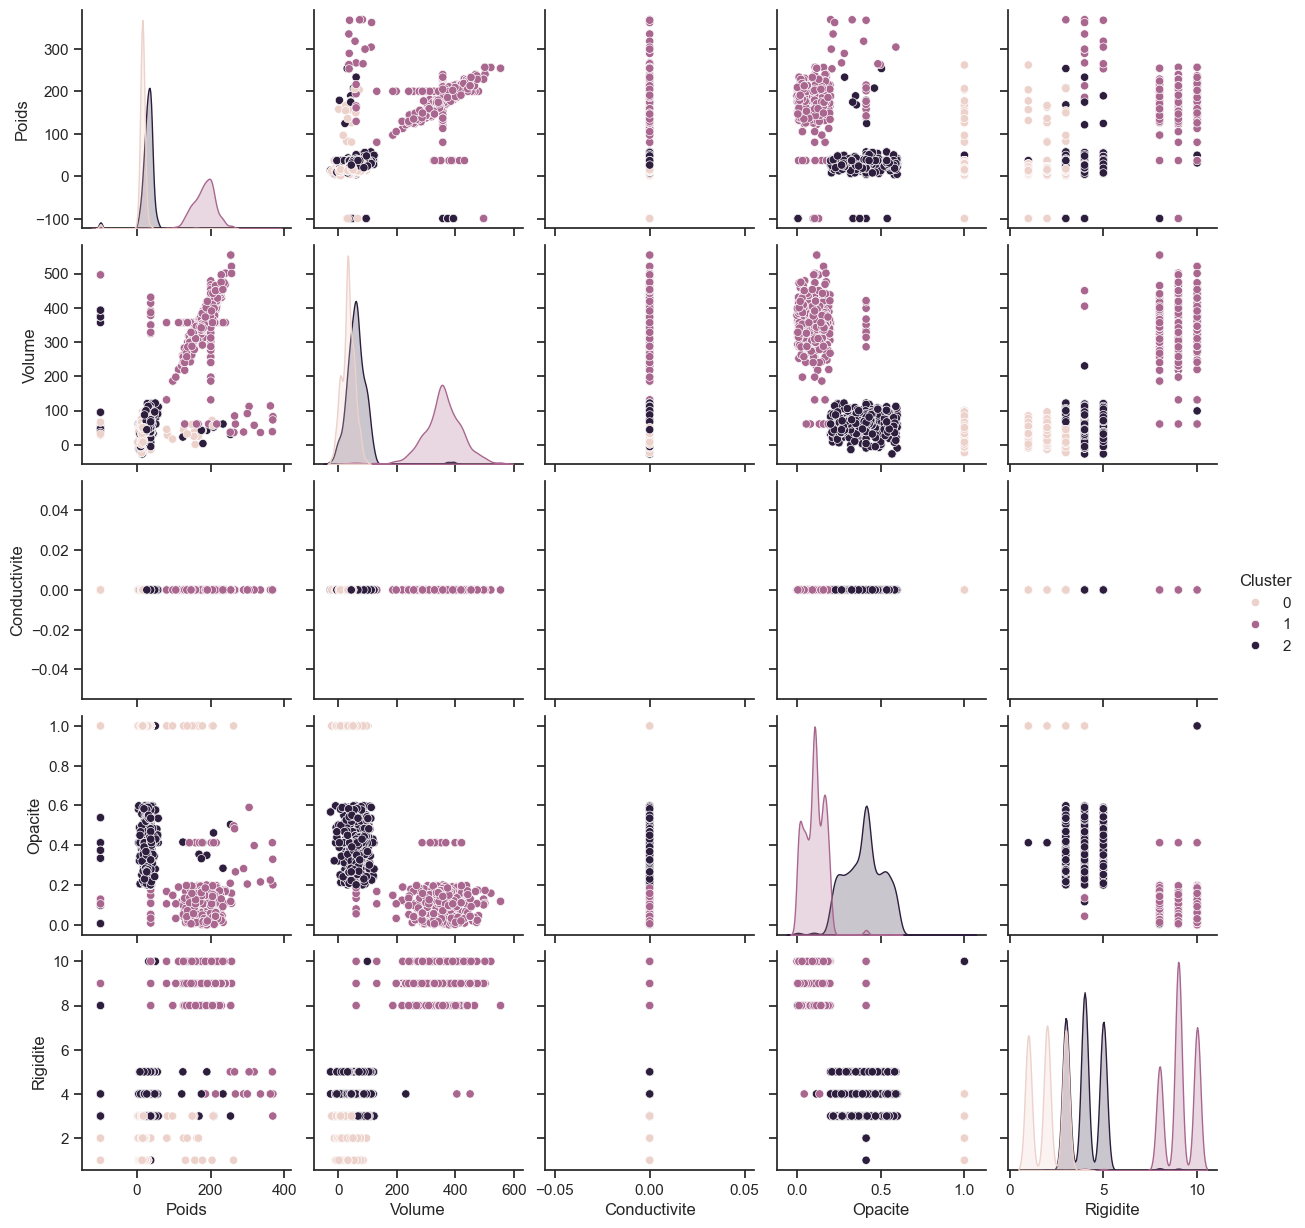

In [624]:
sns.pairplot(df, hue="Cluster", vars=cols)
plt.show()

# NLP

- Nettoyage du texte

In [625]:
import re
import string

def nettoyer_texte(texte):
    texte = str(texte).lower()
    texte = re.sub(r"\d+", " ", texte)          # supprimer les chiffres
    texte = re.sub(r"[^\w\s]", " ", texte)     # supprimer ponctuation
    texte = re.sub(r"\s+", " ", texte)         # supprimer espaces multiples
    return texte.strip()

df["texte_clean"] = df["Rapport_Collecte"].apply(nettoyer_texte)

df[["Rapport_Collecte", "texte_clean"]].head()

,Rapport_Collecte,texte_clean
0,Lot de papier récupéré dans un site non rensei...,lot de papier récupéré dans un site non rensei...
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",lot plastique à l usine a volume l poids kg as...
2,Bris de verre ou contenants en provenance de l...,bris de verre ou contenants en provenance de l...
3,Feuilles et cartons collectés au Centre de Tri...,feuilles et cartons collectés au centre de tri...
4,Déchet de type papier identifié à l'Usine B. V...,déchet de type papier identifié à l usine b vo...


- Tokenisation

In [626]:
df["tokens"] = df["Rapport_Collecte"].astype(str).str.lower().str.split()

df[["Rapport_Collecte", "tokens"]].head()

,Rapport_Collecte,tokens
0,Lot de papier récupéré dans un site non rensei...,"[lot, de, papier, récupéré, dans, un, site, no..."
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...","[lot, plastique, à, l'usine, a., volume, 64.7,..."
2,Bris de verre ou contenants en provenance de l...,"[bris, de, verre, ou, contenants, en, provenan..."
3,Feuilles et cartons collectés au Centre de Tri...,"[feuilles, et, cartons, collectés, au, centre,..."
4,Déchet de type papier identifié à l'Usine B. V...,"[déchet, de, type, papier, identifié, à, l'usi..."


- Suppression des stopwords

In [627]:

stopwords_fr = [
    "le", "la", "les", "un", "une", "des", "du", "de", "d", "et",
    "en", "dans", "sur", "pour", "par", "avec", "au", "aux",
    "ce", "ces", "cet", "cette", "est", "sont", "a", "ont",
    "plus", "moins", "très", "comme", "que", "qui"
]

stopwords_domaine = [
    "collecte", "rapport", "dechet", "dechets", "tri", "centre",
    "papier", "plastique", "verre", "metal", "métal",
    "carton", "cartons", "feuilles"
]

stopwords_total = stopwords_fr + stopwords_domaine

def supprimer_stopwords(texte):
    mots = texte.split()
    mots = [mot for mot in mots if mot not in stopwords_total]
    return " ".join(mots)

df["texte_clean"] = df["texte_clean"].apply(supprimer_stopwords)

df[["Rapport_Collecte", "texte_clean"]].head()

,Rapport_Collecte,texte_clean
0,Lot de papier récupéré dans un site non rensei...,lot récupéré site non renseigné poids léger kg...
1,"Lot plastique à l'Usine A. Volume 64.7 L, poid...",lot à l usine volume l poids kg aspect indéter...
2,Bris de verre ou contenants en provenance de l...,bris ou contenants provenance l usine b masse ...
3,Feuilles et cartons collectés au Centre de Tri...,collectés masse totale non mesuré kg matériau ...
4,Déchet de type papier identifié à l'Usine B. V...,déchet type identifié à l usine b volume estim...


- Stemming

In [628]:
import nltk
from nltk.stem.snowball import FrenchStemmer

stemmer = FrenchStemmer()

def appliquer_stemming(texte):
    mots = texte.split()
    mots_stem = [stemmer.stem(mot) for mot in mots]
    return " ".join(mots_stem)

df["texte_clean"] = df["Rapport_Collecte"].apply(nettoyer_texte)
df["texte_clean"] = df["texte_clean"].apply(supprimer_stopwords)
df["texte_stem"] = df["texte_clean"].apply(appliquer_stemming)

df[["texte_clean", "texte_stem"]].head()

,texte_clean,texte_stem
0,lot récupéré site non renseigné poids léger kg...,lot récuper sit non renseign poid leg kg volum...
1,lot à l usine volume l poids kg aspect indéter...,lot à l usin volum l poid kg aspect indétermin...
2,bris ou contenants provenance l usine b masse ...,bris ou conten proven l usin b mass non mesur ...
3,collectés masse totale non mesuré kg matériau ...,collect mass total non mesur kg matériau leg s...
4,déchet type identifié à l usine b volume estim...,déchet typ identifi à l usin b volum estim l p...


- Bag of Words

In [629]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()
X_bow = bow.fit_transform(df["texte_stem"])
print("Shape Bag of Words :", X_bow.shape)
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=bow.get_feature_names_out()
)
df_bow.head()

Shape Bag of Words : (7286, 125)


,absent,achemin,agent,ambigu,analys,anomal,anormal,aspect,atyp,aucun,...,variabl,ver,vi,visuel,volum,vérif,électr,élev,état,étiquetag
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


- Séparation train/test

In [630]:
from sklearn.model_selection import train_test_split

X = df["texte_stem"]
y = df["Categorie"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille x_train :", x_train.shape)
print("Taille x_test  :", x_test.shape)

Taille x_train : (5828,)
Taille x_test  : (1458,)


In [631]:
X_train_bow = bow.fit_transform(x_train)
X_test_bow = bow.transform(x_test)

model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)

y_pred_bow = model_bow.predict(X_test_bow)

print(classification_report(y_test, y_pred_bow, zero_division=0))

              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458



- Word2Vec

In [634]:
from gensim.models import Word2Vec
import numpy as np


phrases_train = [t.split() for t in x_train]
phrases_test = [t.split() for t in x_test]


w2v_model = Word2Vec(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("Word2Vec entraîné ✔")

Word2Vec entraîné ✔


In [635]:
def vectoriser_w2v(texte, model):
    mots = texte.split()
    
    vecteurs = []
    for mot in mots:
        if mot in model.wv:
            vecteurs.append(model.wv[mot])
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

In [636]:
X_train_w2v = np.array([vectoriser_w2v(t, w2v_model) for t in x_train])
X_test_w2v = np.array([vectoriser_w2v(t, w2v_model) for t in x_test])

print("Shape Word2Vec:", X_train_w2v.shape)

Shape Word2Vec: (5828, 100)


In [637]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_w2v = LogisticRegression(max_iter=1000)

model_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = model_w2v.predict(X_test_w2v)

print("===== Word2Vec =====")
print(classification_report(y_test, y_pred_w2v, zero_division=0))

===== Word2Vec =====
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458



- FastText

In [638]:
from gensim.models import FastText

fast_model = FastText(
    sentences=phrases_train,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

print("FastText entraîné ✔")

FastText entraîné ✔


In [639]:
def vectoriser_fasttext(texte, model):
    mots = texte.split()
    
    vecteurs = []
    for mot in mots:
        vecteurs.append(model.wv[mot])  # FastText يتعامل حتى مع mots inconnus
    
    if len(vecteurs) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vecteurs, axis=0)

In [640]:
X_train_fast = np.array([vectoriser_fasttext(t, fast_model) for t in x_train])
X_test_fast = np.array([vectoriser_fasttext(t, fast_model) for t in x_test])

print("Shape FastText:", X_train_fast.shape)

Shape FastText: (5828, 100)


In [641]:
model_fast = LogisticRegression(max_iter=1000)

model_fast.fit(X_train_fast, y_train)

y_pred_fast = model_fast.predict(X_test_fast)

print("===== FastText =====")
print(classification_report(y_test, y_pred_fast, zero_division=0))

===== FastText =====
              precision    recall  f1-score   support

      Papier       0.99      0.97      0.98       417
   Plastique       0.98      0.99      0.98       583
       Verre       0.99      1.00      0.99       458

    accuracy                           0.99      1458
   macro avg       0.99      0.99      0.99      1458
weighted avg       0.99      0.99      0.99      1458



- Transformation texte avec TF-IDF

In [642]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)

print("Shape TF-IDF train :", X_train_tfidf.shape)
print("Shape TF-IDF test  :", X_test_tfidf.shape)

Shape TF-IDF train : (5828, 602)
Shape TF-IDF test  : (1458, 602)


In [643]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modeles = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for nom, modele in modeles.items():
    modele.fit(X_train_tfidf, y_train)
    y_pred = modele.predict(X_test_tfidf)
    
    print("\n======================")
    print(nom)
    print("======================")
    print(classification_report(y_test, y_pred, zero_division=0))


Naive Bayes
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458


Logistic Regression
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458


LinearSVC
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1

- Modèle NLP : Logistic Regression

In [644]:
from sklearn.linear_model import LogisticRegression

modele_nlp = LogisticRegression(max_iter=1000)

modele_nlp.fit(X_train_tfidf, y_train)

y_pred_nlp = modele_nlp.predict(X_test_tfidf)

In [645]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred_nlp))

print("\nAccuracy  :", accuracy_score(y_test, y_pred_nlp))
print("Recall    :", recall_score(y_test, y_pred_nlp, average="macro", zero_division=0))
print("Precision :", precision_score(y_test, y_pred_nlp, average="macro", zero_division=0))
print("F1-score  :", f1_score(y_test, y_pred_nlp, average="macro", zero_division=0))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_nlp, zero_division=0))

Confusion Matrix :
[[417   0   0]
 [  0 583   0]
 [  0   0 458]]

Accuracy  : 1.0
Recall    : 1.0
Precision : 1.0
F1-score  : 1.0

Classification Report :
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458



- Pipeline complet plus propre

In [646]:
from sklearn.pipeline import Pipeline

pipeline_nlp = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_nlp.fit(x_train, y_train)

y_pred_pipeline = pipeline_nlp.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred_pipeline))
print("F1-score :", f1_score(y_test, y_pred_pipeline, average="macro", zero_division=0))
print(classification_report(y_test, y_pred_pipeline, zero_division=0))

Accuracy : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

      Papier       1.00      1.00      1.00       417
   Plastique       1.00      1.00      1.00       583
       Verre       1.00      1.00      1.00       458

    accuracy                           1.00      1458
   macro avg       1.00      1.00      1.00      1458
weighted avg       1.00      1.00      1.00      1458



In [647]:
print(y_test.value_counts())

Categorie
Plastique    583
Verre        458
Papier       417
Name: count, dtype: int64


In [648]:
exemples = [
    "Le matériau est transparent, cassant et provient de bouteilles.",
    "Déchet léger, souple, utilisé pour les emballages.",
    "Matériau conducteur, rigide et recyclable.",
    "Déchet composé de feuilles et cartons."
]

predictions = pipeline_nlp.predict(exemples)

for texte, pred in zip(exemples, predictions):
    print("Texte :", texte)
    print("Catégorie prédite :", pred)
    print("----------------------")

Texte : Le matériau est transparent, cassant et provient de bouteilles.
Catégorie prédite : Verre
----------------------
Texte : Déchet léger, souple, utilisé pour les emballages.
Catégorie prédite : Plastique
----------------------
Texte : Matériau conducteur, rigide et recyclable.
Catégorie prédite : Papier
----------------------
Texte : Déchet composé de feuilles et cartons.
Catégorie prédite : Plastique
----------------------


In [649]:
import joblib

joblib.dump(pipeline_nlp, "model_nlp.pkl")

['model_nlp.pkl']